# Perceptron


## Import Libraries


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split


## Load Dataset


In [2]:
X, y = make_classification(n_samples=100, n_features=2, n_informative=2, n_redundant=0, n_clusters_per_class=1, random_state=42)


## Preprocessing


In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


## Model Implementation


In [4]:
class Perceptron:
    def __init__(self, learning_rate=0.01, epochs=50):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = 0

    def activation(self, z):
        return np.where(z >= 0, 1, 0)

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        for _ in range(self.epochs):
            for idx, x_i in enumerate(X):
                linear_output = np.dot(x_i, self.weights) + self.bias
                y_predicted = self.activation(linear_output)
                update = self.learning_rate * (y[idx] - y_predicted)
                self.weights += update * x_i
                self.bias += update

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return self.activation(linear_output)


## Model Training


In [5]:
model = Perceptron(learning_rate=0.05, epochs=50)
model.fit(X_train, y_train)
print("Trained Weights:", model.weights)
print("Trained Bias:", model.bias)


Trained Weights: [-0.06224473  0.05604908]
Trained Bias: 0.05


## Prediction


In [6]:
y_pred = model.predict(X_test)
print("Actual:", y_test)
print("Predicted:", y_pred)


Actual: [1 1 1 1 0 0 0 1 0 0 0 1 0 0 0 1 1 0 1 1]
Predicted: [1 1 1 1 0 0 0 1 0 0 0 1 0 0 0 1 1 0 1 1]


## Evaluation


In [7]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")


Accuracy: 1.0000


## Visualization


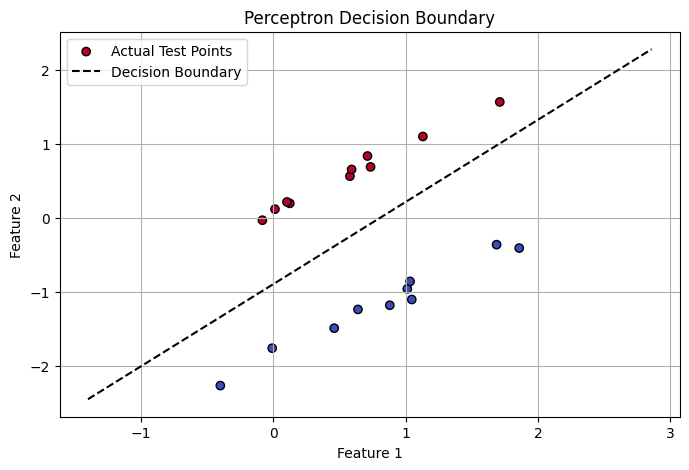

In [8]:
plt.figure(figsize=(8, 5))
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap="coolwarm", marker="o", edgecolors="k", label="Actual Test Points")
x_vals = np.linspace(X_test[:, 0].min() - 1, X_test[:, 0].max() + 1, 100)
slope = -model.weights[0] / model.weights[1]
intercept = -model.bias / model.weights[1]
plt.plot(x_vals, slope * x_vals + intercept, color="black", linestyle="--", label="Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Perceptron Decision Boundary")
plt.legend()
plt.grid(True)
plt.show()
